In [13]:
# 1. 导入所需库
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#将生成的静态图嵌入notebook中
%matplotlib inline  
plt.rcParams['font.sans-serif']=['SimHei']   # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False     # 用来正常显示负号

In [14]:
# 2. 获取数据
# 使用read_csv()函数进行读取
starbucks = pd.read_csv('starbucks.csv', encoding='utf-8')
starbucks.head()

,Brand,Store Number,Store Name,Ownership Type,Street Address,City,State/Province,Country,Postcode,Phone Number,Timezone,Longitude,Latitude
0,Starbucks,47370-257954,"Meritxell, 96",Licensed,"Av. Meritxell, 96",Andorra la Vella,7,AD,AD500,376818720,GMT+1:00 Europe/Andorra,1.53,42.51
1,Starbucks,22331-212325,Ajman Drive Thru,Licensed,"1 Street 69, Al Jarf",Ajman,AJ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,55.47,25.42
2,Starbucks,47089-256771,Dana Mall,Licensed,Sheikh Khalifa Bin Zayed St.,Ajman,AJ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,55.47,25.39
3,Starbucks,22126-218024,Twofour 54,Licensed,Al Salam Street,Abu Dhabi,AZ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,54.38,24.48
4,Starbucks,17127-178586,Al Ain Tower,Licensed,"Khaldiya Area, Abu Dhabi Island",Abu Dhabi,AZ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,54.54,24.51


In [15]:
# 3. 数据预处理——查看数据基本信息
print('数据形状：', starbucks.shape)
print('列名：', starbucks.columns.tolist())
print('缺失值统计：')
print(starbucks.isnull().sum())
starbucks.info()

数据形状： (25600, 13)
列名： ['Brand', 'Store Number', 'Store Name', 'Ownership Type', 'Street Address', 'City', 'State/Province', 'Country', 'Postcode', 'Phone Number', 'Timezone', 'Longitude', 'Latitude']
缺失值统计：
Brand                0
Store Number         0
Store Name           0
Ownership Type       0
Street Address       2
City                15
State/Province       0
Country              0
Postcode          1522
Phone Number      6861
Timezone             0
Longitude            1
Latitude             1
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25600 entries, 0 to 25599
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           25600 non-null  object 
 1   Store Number    25600 non-null  object 
 2   Store Name      25600 non-null  object 
 3   Ownership Type  25600 non-null  object 
 4   Street Address  25598 non-null  object 
 5   City            25585 non-null  object 
 6   State/P

In [16]:
# 4. 数据分析及可视化
# 4.1 查看星巴克旗下品牌，并获取全球门店总数
brands = starbucks['Brand'].unique()        # 获取品牌唯一值
print('星巴克旗下品牌：')
for brand in brands:
    count = starbucks[starbucks['Brand'] == brand].shape[0]
    print(f'  {brand}：{count} 家')

total_stores = starbucks.shape[0]            # 统计全球门店总数
print(f'\n全球星巴克门店总数：{total_stores} 家')

# 使用value_counts()快速统计各品牌数量
brand_counts = starbucks['Brand'].value_counts()
brand_counts

星巴克旗下品牌：
  Starbucks：25249 家
  Teavana：348 家
  Evolution Fresh：2 家
  Coffee House Holdings：1 家

全球星巴克门店总数：25600 家


Brand
Starbucks                25249
Teavana                    348
Evolution Fresh              2
Coffee House Holdings        1
Name: count, dtype: int64

In [17]:
# 4.2 查看全球共多少国家和地区开设了星巴克门店，显示前十
country_counts = starbucks['Country'].value_counts()      # 按国家统计门店数量
total_countries = country_counts.shape[0]                  # 获取国家/地区总数
print(f'全球共有 {total_countries} 个国家和地区开设了星巴克门店')
print('\n门店数量排名前10的国家/地区：')
country_counts.head(10)

全球共有 73 个国家和地区开设了星巴克门店

门店数量排名前10的国家/地区：


Country
US    13608
CN     2734
CA     1468
JP     1237
KR      993
GB      901
MX      579
TW      394
TR      326
PH      298
Name: count, dtype: int64

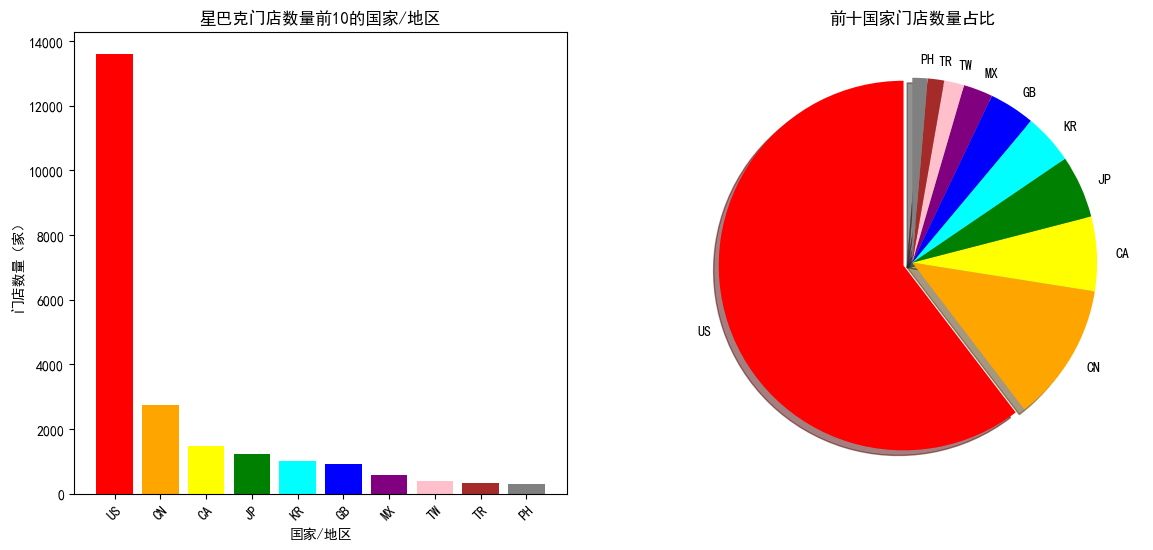

In [18]:
# 4.3 绘制前十国家的分布情况
top10_countries = country_counts.head(10)     # 获取前十国家数据

# 设置画布尺寸
plt.figure(figsize=(14, 6))

# 子图1：柱形图——展示前十国家门店数量
plt.subplot(1, 2, 1)
bars = plt.bar(top10_countries.index, top10_countries.values, 
               color=['red', 'orange', 'yellow', 'green', 'cyan', 
                      'blue', 'purple', 'pink', 'brown', 'gray'])
plt.title('星巴克门店数量前10的国家/地区')
plt.xlabel('国家/地区')
plt.ylabel('门店数量（家）')
plt.xticks(rotation=45)                       # 旋转x轴标签避免重叠

# 子图2：饼图——展示前十国家门店数量占比
plt.subplot(1, 2, 2)
explode = (0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0)  # 突出显示美国
plt.pie(top10_countries.values, labels=top10_countries.index, 
        colors=['red', 'orange', 'yellow', 'green', 'cyan', 
                'blue', 'purple', 'pink', 'brown', 'gray'],
        explode=explode, shadow=True, startangle=90)
plt.title('前十国家门店数量占比')

# 保存图片
plt.savefig('前十国家分布.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# 4.4 显示拥有星巴克门店数量前10的城市
city_counts = starbucks['City'].value_counts()   # 按城市统计门店数量
print('全球星巴克门店数量排名前10的城市：')
city_counts.head(10)

全球星巴克门店数量排名前10的城市：


City
上海市            542
Seoul          243
北京市            234
New York       232
London         216
Toronto        192
Chicago        180
Mexico City    180
Seattle        156
Las Vegas      156
Name: count, dtype: int64

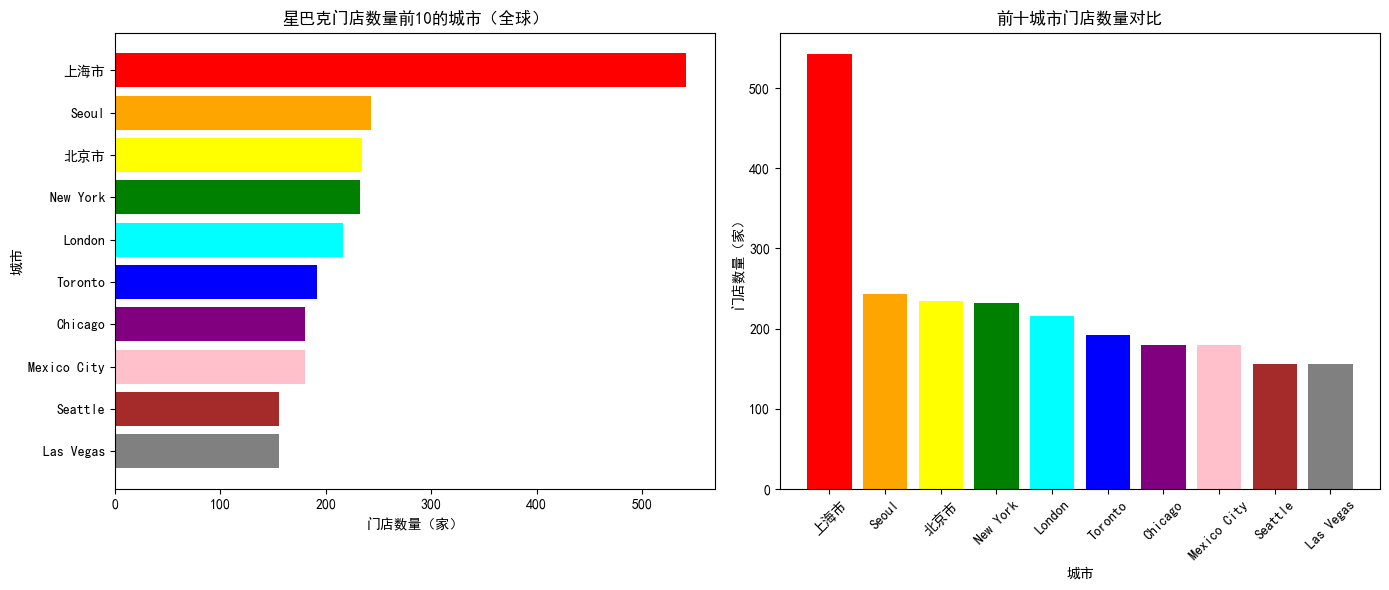

In [20]:
# 4.5 绘制前十城市的分布情况
top10_cities = city_counts.head(10)

# 设置画布尺寸
plt.figure(figsize=(14, 6))

# 子图1：水平条形图——城市名称较长，水平方向展示更清晰
plt.subplot(1, 2, 1)
top10_cities_asc = top10_cities[::-1]             # 逆序使排名第一的在上方
plt.barh(top10_cities_asc.index, top10_cities_asc.values,
         color=['gray', 'brown', 'pink', 'purple', 'blue', 
                'cyan', 'green', 'yellow', 'orange', 'red'])
plt.title('星巴克门店数量前10的城市（全球）')
plt.xlabel('门店数量（家）')
plt.ylabel('城市')

# 子图2：柱形图——直观对比各城市门店数量
plt.subplot(1, 2, 2)
plt.bar(range(len(top10_cities)), top10_cities.values,
        color=['red', 'orange', 'yellow', 'green', 'cyan', 
               'blue', 'purple', 'pink', 'brown', 'gray'])
plt.title('前十城市门店数量对比')
plt.xlabel('城市')
plt.ylabel('门店数量（家）')
plt.xticks(range(len(top10_cities)), top10_cities.index, rotation=45)

plt.tight_layout()
plt.show()

In [21]:
# 4.6 按照星巴克门店在中国的分布情况，统计并绘制排名前10的城市
# 筛选中国地区的数据
china_starbucks = starbucks[starbucks['Country'] == 'CN']
china_city_counts = china_starbucks['City'].value_counts()
print('中国星巴克门店数量排名前10的城市：')
china_top10 = china_city_counts.head(10)
china_top10

中国星巴克门店数量排名前10的城市：


City
上海市          542
北京市          234
杭州市          117
深圳市          113
广州市          106
Hong Kong    104
成都市           98
苏州市           90
南京市           73
武汉市           67
Name: count, dtype: int64

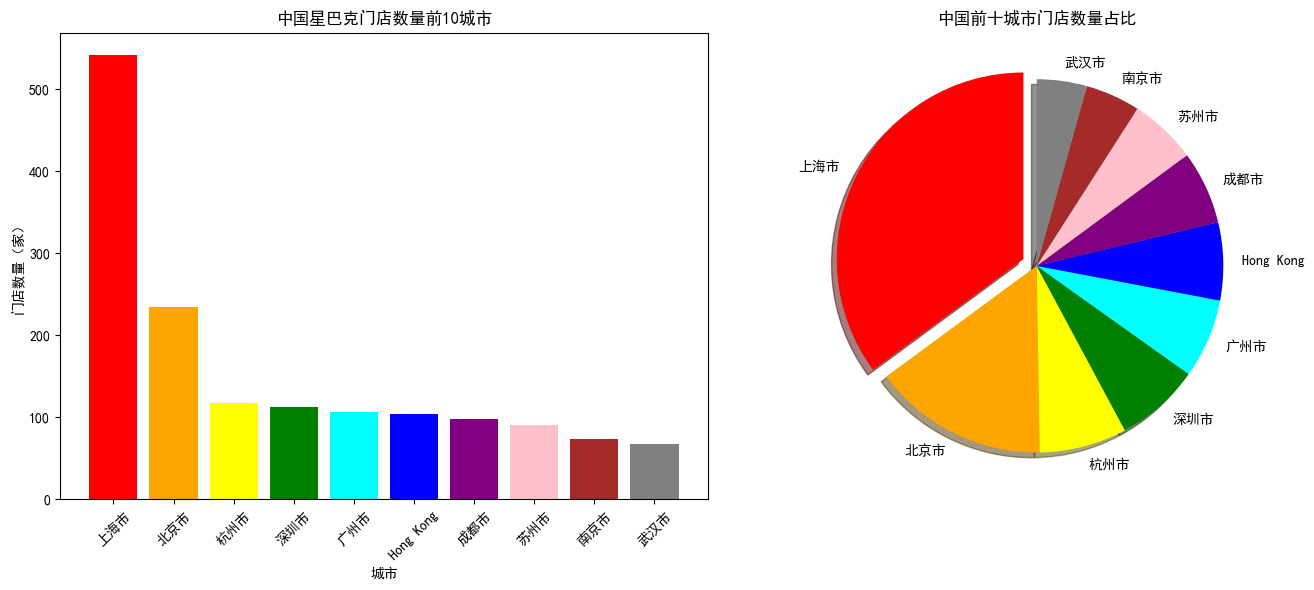

中国共有星巴克门店：2734 家
分布城市数量：197 个


In [22]:
# 绘制中国前十城市分布图
# 设置画布尺寸
plt.figure(figsize=(14, 6))

# 子图1：柱形图——展示中国前十城市的门店数量
plt.subplot(1, 2, 1)
plt.bar(range(len(china_top10)), china_top10.values,
        color=['red', 'orange', 'yellow', 'green', 'cyan', 
               'blue', 'purple', 'pink', 'brown', 'gray'])
plt.title('中国星巴克门店数量前10城市')
plt.xlabel('城市')
plt.ylabel('门店数量（家）')
plt.xticks(range(len(china_top10)), china_top10.index, rotation=45)

# 子图2：饼图——展示各城市门店占比
plt.subplot(1, 2, 2)
explode = (0.08, 0, 0, 0, 0, 0, 0, 0, 0, 0)     # 突出显示上海
plt.pie(china_top10.values, labels=china_top10.index,
        colors=['red', 'orange', 'yellow', 'green', 'cyan', 
                'blue', 'purple', 'pink', 'brown', 'gray'],
        explode=explode, shadow=True, startangle=90)
plt.title('中国前十城市门店数量占比')

plt.tight_layout()
plt.show()

print(f'中国共有星巴克门店：{china_starbucks.shape[0]} 家')
print(f'分布城市数量：{china_starbucks["City"].nunique()} 个')

In [23]:
# 4.7 绘制星巴克门店的经营方式
# 统计各经营方式的门店数量
ownership_counts = starbucks['Ownership Type'].value_counts()
print('星巴克门店经营方式统计：')
for otype, count in ownership_counts.items():
    print(f'  {otype}：{count} 家  ({count/total_stores*100:.1f}%)')
ownership_counts

星巴克门店经营方式统计：
  Company Owned：11932 家  (46.6%)
  Licensed：9375 家  (36.6%)
  Joint Venture：3976 家  (15.5%)
  Franchise：317 家  (1.2%)


Ownership Type
Company Owned    11932
Licensed          9375
Joint Venture     3976
Franchise          317
Name: count, dtype: int64

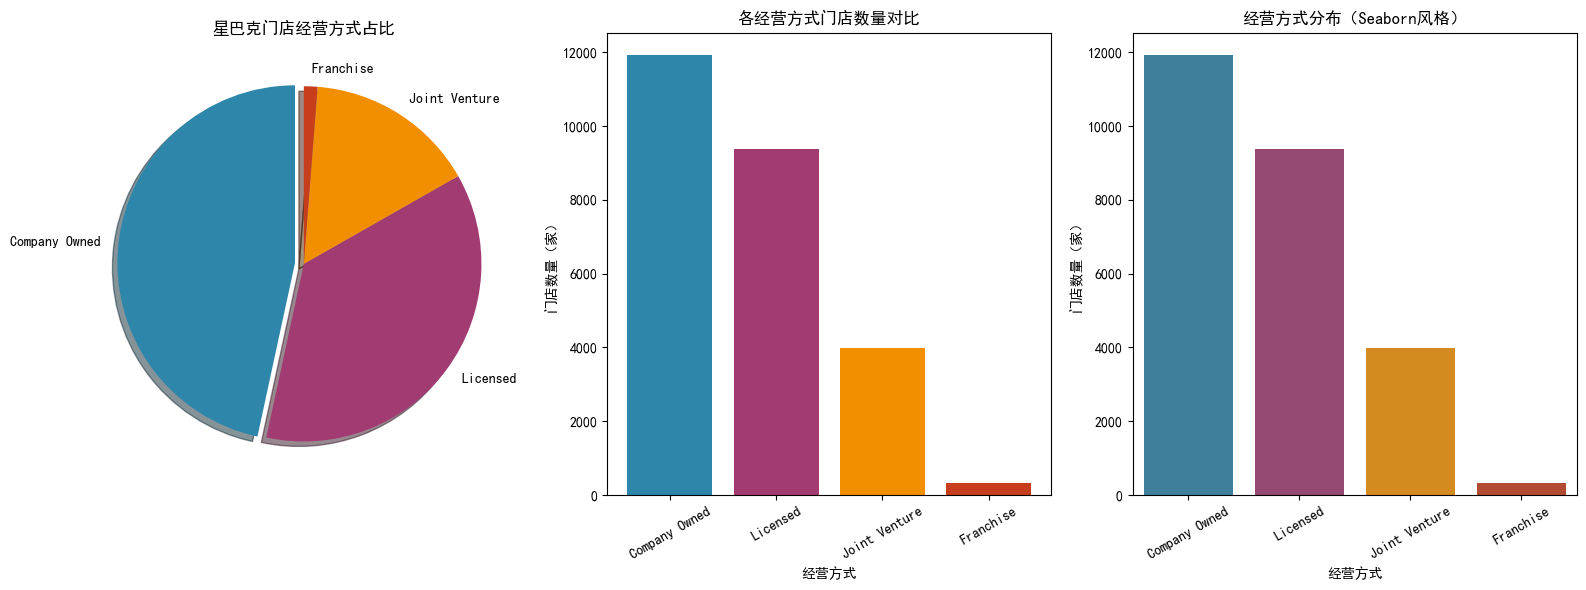

In [24]:
# 使用三图展示：饼图、matplotlib柱形图、seaborn柱形图
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['font.sans-serif']=['SimHei']   # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False     # 用来正常显示负号

ownership_colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

# 设置画布尺寸
plt.figure(figsize=(16, 6))

# 子图1：饼图——展示经营方式整体占比
plt.subplot(1, 3, 1)
plt.pie(ownership_counts.values, labels=ownership_counts.index,
        colors=ownership_colors, explode=(0.05, 0, 0, 0),
        shadow=True, startangle=90)
plt.title('星巴克门店经营方式占比')

# 子图2：matplotlib柱形图——直观对比不同经营方式的数量
plt.subplot(1, 3, 2)
plt.bar(ownership_counts.index, ownership_counts.values, 
        color=ownership_colors)
plt.title('各经营方式门店数量对比')
plt.xlabel('经营方式')
plt.ylabel('门店数量（家）')
plt.xticks(rotation=30)

# 子图3：使用seaborn的barplot()绘制
plt.subplot(1, 3, 3)
import seaborn as sns
sns.barplot(x=ownership_counts.index, y=ownership_counts.values,
            hue=ownership_counts.index, palette=ownership_colors, legend=False)
plt.title('经营方式分布（Seaborn风格）')
plt.xlabel('经营方式')
plt.ylabel('门店数量（家）')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()